# Extract Kinematic Features from GAVD Datasets

## 1.  Setup

In [1]:
# Configure matplotlib FIRST before any other imports
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Verify matplotlib backend
print(f"Matplotlib backend: {matplotlib.get_backend()}")

# Enable interactive mode
plt.ion()

Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Suppress TensorFlow and MediaPipe logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import sys
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Setup paths
project_root = Path.cwd().parent.parent
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp4" / "data"

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

Project root: /Users/pmui/dev/alex/alexpose
Data root: /Users/pmui/dev/alex/alexpose/experiments/exp4/data
Video path: /Users/pmui/dev/alex/alexpose/data/youtube


In [3]:
from ambient.gavd import GAVDDataLoader
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.pose.joint_angles import get_joint_angles


print("✓ Imports successful")

✓ Imports successful


## 2. Explore Training Dataset

In [4]:
data_root

PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data')

In [5]:
# Get condition directories
condition_paths = [
    p for p in data_root.iterdir() 
    if p.is_dir() and p.name[0] in string.ascii_letters
]

len(condition_paths)

5

In [6]:

print(f"Found {len(condition_paths)} conditions:\n")
for path in sorted(condition_paths):
    csv_files = list(path.glob("*.csv"))
    print(f"  {path.name:15s}: {len(csv_files)} CSV files")

Found 5 conditions:

  cerebralpalsy  : 15 CSV files
  myopathic      : 20 CSV files
  normal         : 12 CSV files
  parkinsons     : 9 CSV files
  stroke         : 12 CSV files


## 3.  Extract Keypoints from One Gait (CSV) Sequence

In [7]:
condition_paths

[PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/stroke'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/myopathic'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/parkinsons'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/normal'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/cerebralpalsy')]

In [8]:
normal_path = condition_paths[3]
stroke_path = condition_paths[0]
parkinsons_path = condition_paths[2]
myopathic_path = condition_paths[1]
cerebralpalsy_path = condition_paths[4]

normal_path, stroke_path, parkinsons_path, myopathic_path, cerebralpalsy_path

(PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/normal'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/stroke'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/parkinsons'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/myopathic'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/cerebralpalsy'))

In [9]:
# Let's get the first CSV from the normal_path
normal_csv = list(normal_path.glob("*.csv"))[11]
stroke_csv = list(stroke_path.glob("*.csv"))[0]
parkinsons_csv = list(parkinsons_path.glob("*.csv"))[3]
myopathic_csv = list(myopathic_path.glob("*.csv"))[1]
cerebralpalsy_csv = list(cerebralpalsy_path.glob("*.csv"))[1]
normal_csv, stroke_csv, parkinsons_csv

(PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/normal/cljo32213001u3n6lel97up5f.csv'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/stroke/cljvvsucg00043n6l4evgn7q4.csv'),
 PosixPath('/Users/pmui/dev/alex/alexpose/experiments/exp4/data/parkinsons/cljnz5sb1000o3n6lntosswwz.csv'))

In [10]:
gavd_loader = GAVDDataLoader()

normal_df = gavd_loader.load_gavd_data(normal_csv)
stroke_df = gavd_loader.load_gavd_data(stroke_csv)
parkinsons_df = gavd_loader.load_gavd_data(parkinsons_csv)
myopathic_df = gavd_loader.load_gavd_data(myopathic_csv)
cerebralpalsy_df = gavd_loader.load_gavd_data(cerebralpalsy_csv)


normal_df.shape, stroke_df.shape, parkinsons_df.shape, myopathic_df.shape, cerebralpalsy_df.shape

((70, 12), (166, 12), (81, 12), (153, 12), (152, 12))

In [11]:
normal_sid = normal_df.iloc[0]["seq"]
stroke_sid = stroke_df.iloc[0]["seq"]
parkinsons_sid = parkinsons_df.iloc[0]["seq"]
myopathic_sid = myopathic_df.iloc[0]["seq"]
cerebralpalsy_sid = cerebralpalsy_df.iloc[0]["seq"]

normal_sid, stroke_sid, parkinsons_sid, myopathic_sid, cerebralpalsy_sid

('cljo32213001u3n6lel97up5f',
 'cljvvsucg00043n6l4evgn7q4',
 'cljnz5sb1000o3n6lntosswwz',
 'cljo83yl800513n6lfglf5jn8',
 'cljarbn1y00cg3n6l1u4i0d5l')

In [12]:
video_base_path

PosixPath('/Users/pmui/dev/alex/alexpose/data/youtube')

In [13]:
extractor = SequenceKeypointExtractor()
normal_keypoints_array = extractor.extract_from_sequence(
    sequence_data=normal_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
stroke_keypoints_array = extractor.extract_from_sequence(
    sequence_data=stroke_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
parkinsons_keypoints_array = extractor.extract_from_sequence(
    sequence_data=parkinsons_df,
    video_base_path=video_base_path, 
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
myopathic_keypoints_array = extractor.extract_from_sequence(
    sequence_data=myopathic_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)
cerebralpalsy_keypoints_array = extractor.extract_from_sequence(
    sequence_data=cerebralpalsy_df,
    video_base_path=video_base_path,
    filter_empty=True,    # remove frames with <25 keypoints
    min_keypoints=25,     # at least 25 of the 33 keypoints to be valid
    verbose=True
)


I0000 00:00:1769551849.071444 43186413 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1769551849.121145 43186416 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769551849.130333 43186418 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-27 14:10:49.131 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:434 - Processing sequence: cljo32213001u3n6lel97up5f (70 frames)


	frame 561 (1/70)


W0000 00:00:1769551849.605426 43186424 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


	frame 571 (11/70)
	frame 581 (21/70)
	frame 591 (31/70)
	frame 601 (41/70)
	frame 611 (51/70)
	frame 621 (61/70)


2026-01-27 14:11:04.371 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:459 - Processed 70/70 frames successfully
2026-01-27 14:11:04.371 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:547 - Filtered to 70/70 frames (min 25 keypoints, removed 0)
2026-01-27 14:11:04.373 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:434 - Processing sequence: cljvvsucg00043n6l4evgn7q4 (166 frames)


...

2026-01-27 14:13:11.975 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:459 - Processed 153/153 frames successfully
2026-01-27 14:13:11.975 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:547 - Filtered to 144/153 frames (min 25 keypoints, removed 9)
2026-01-27 14:13:11.976 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:434 - Processing sequence: cljarbn1y00cg3n6l1u4i0d5l (152 frames)


	frame 2026 (1/152)
	frame 2036 (11/152)
	frame 2046 (21/152)
	frame 2056 (31/152)


I0000 00:00:1769552001.001327 43250576 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1769552001.053032 43250580 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769552001.062499 43250585 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


	frame 2066 (41/152)
	frame 2076 (51/152)
	frame 2086 (61/152)
	frame 2096 (71/152)
	frame 2106 (81/152)
	frame 2116 (91/152)
	frame 2126 (101/152)
	frame 2136 (111/152)
	frame 2146 (121/152)
	frame 2156 (131/152)
	frame 2166 (141/152)
	frame 2176 (151/152)


2026-01-27 14:14:07.095 | INFO     | ambient.pose.keypoint_extractor:_process_all_frames:459 - Processed 152/152 frames successfully
2026-01-27 14:14:07.097 | INFO     | ambient.pose.keypoint_extractor:_filter_keypoints:547 - Filtered to 152/152 frames (min 25 keypoints, removed 0)


In [14]:
len(normal_keypoints_array), \
len(stroke_keypoints_array), \
len(parkinsons_keypoints_array), \
len(cerebralpalsy_keypoints_array), \
len(myopathic_keypoints_array)

(70, 166, 81, 152, 144)

In [15]:
len(normal_keypoints_array[9].keypoints), \
len(stroke_keypoints_array[0].keypoints), \
len(parkinsons_keypoints_array[0].keypoints), \
len(myopathic_keypoints_array[0].keypoints), \
len(cerebralpalsy_keypoints_array[0].keypoints) 

(33, 33, 33, 33, 33)

In [16]:
# let's look at the first keypoint at frame 0
normal_keypoints_array[0].keypoints[32]

Keypoint(id=32, name='RIGHT_FOOT_INDEX', x=159.48352199792862, y=300.57076692581177, z=0.1392430067062378, confidence=0.9443912506103516, visibility=0.9443912506103516, presence=0.9818337559700012, x_normalized=0.3228411376476288, y_normalized=0.8349187970161438)

In [17]:
from pprint import pprint

print(vars(normal_keypoints_array[0].keypoints[0]))

{'id': 0, 'name': 'NOSE', 'x': 170.4065025448799, 'y': 74.68664646148682, 'z': -0.41655421257019043, 'confidence': 0.9998944997787476, 'visibility': 0.9998944997787476, 'presence': 0.9989629983901978, 'x_normalized': 0.34495243430137634, 'y_normalized': 0.20746290683746338}


## 4.  Calculate Frame-by-Frame Joint Angles

In [18]:
normal_joint_angles = get_joint_angles(
    keypoints_array=normal_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=normal_sid
)
stroke_joint_angles = get_joint_angles(
    keypoints_array=stroke_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=stroke_sid
)
parkinsons_joint_angles = get_joint_angles(
    keypoints_array=parkinsons_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=parkinsons_sid
)
myopathic_joint_angles = get_joint_angles(
    keypoints_array=myopathic_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=myopathic_sid
)
cerebralpalsy_joint_angles = get_joint_angles(
    keypoints_array=cerebralpalsy_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=cerebralpalsy_sid
)
# let's see which joint angles are calculated for Frame 0 (same for all other frames)
print(normal_joint_angles.frames[0].angles.keys())

dict_keys(['left_hip', 'left_knee', 'right_hip', 'right_knee', 'left_ankle', 'right_ankle'])


In [19]:
print("Normal Gait: Left Hip")
normal_joint_angles.get_statistics("left_hip")

Normal Gait: Left Hip


{'mean': 173.1908092929625,
 'std': 5.411895421436555,
 'min': 161.80018483225604,
 'max': 179.99111556977064,
 'range': 18.190930737514606,
 'valid_count': 70}

In [20]:
print("Stroke Gait: Left Hip")
stroke_joint_angles.get_statistics("left_hip")


Stroke Gait: Left Hip


{'mean': 171.38602466987135,
 'std': 2.2147107519495015,
 'min': 166.38195256255406,
 'max': 176.2545160345279,
 'range': 9.872563471973848,
 'valid_count': 166}

In [21]:
print("Parkinsons Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")

Parkinsons Gait: Left Hip


{'mean': 172.35810744358142,
 'std': 2.9114627009289626,
 'min': 165.37144336175572,
 'max': 178.13752198535806,
 'range': 12.76607862360234,
 'valid_count': 81}

In [22]:
print("Myopathic Gait: Left Hip")
myopathic_joint_angles.get_statistics("left_hip")


Myopathic Gait: Left Hip


{'mean': 169.20339156510812,
 'std': 6.92922060532107,
 'min': 156.40881805193885,
 'max': 179.98898190698617,
 'range': 23.580163855047317,
 'valid_count': 144}

In [23]:
print("Parkinson's Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")


Parkinson's Gait: Left Hip


{'mean': 172.35810744358142,
 'std': 2.9114627009289626,
 'min': 165.37144336175572,
 'max': 178.13752198535806,
 'range': 12.76607862360234,
 'valid_count': 81}

Let's visualize the joint angle changes over a gait sequence

In [24]:
import matplotlib.pyplot as plt

def plot_joint_angles_statistics(name, joint_angles):

    print(f"\nVisualizing joint angles for {name}...")
    print(f"Number of frames with joint angles: {len(joint_angles.frames)}")

    if len(joint_angles.frames) > 0 and len(joint_angles.frames[0].angles) > 0:
        joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
        
        # Create the figure
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"{name} Joint Angles Over Time", fontsize=18, fontweight='bold')
        
        for idx, joint_name in enumerate(joints):
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            try:
                # Get angle data
                angles = joint_angles.get_joint_angle_series(joint_name)
                stats = joint_angles.get_statistics(joint_name)
                
                # Check if we have valid data
                if stats['valid_count'] > 0 and not np.isnan(stats['mean']):
                    # Filter out NaN values
                    valid_mask = ~np.isnan(angles)
                    valid_frames = np.where(valid_mask)[0]
                    valid_angles = angles[valid_mask]
                    
                    if len(valid_angles) > 0:
                        # Plot the angle series
                        ax.plot(valid_frames, valid_angles, 'b-', linewidth=2, alpha=0.7, label='Angle')
                        
                        # Add mean line
                        ax.axhline(y=stats['mean'], color='red', linestyle='--', 
                                linewidth=2, alpha=0.8, label=f"Mean: {stats['mean']:.1f}°")
                        
                        # Add shaded region for std
                        ax.axhspan(stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                alpha=0.2, color='red', label=f"±1 SD")
                        
                        # Formatting
                        ax.set_title(joint_name.replace('_', ' ').title(), 
                                    fontsize=13, fontweight='bold', pad=10)
                        ax.set_xlabel('Frame Number', fontsize=11)
                        ax.set_ylabel('Angle (degrees)', fontsize=11)
                        ax.legend(loc='best', fontsize=9, framealpha=0.9)
                        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
                        
                        # Set reasonable y-axis limits
                        y_margin = (stats['max'] - stats['min']) * 0.1
                        ax.set_ylim(stats['min'] - y_margin, stats['max'] + y_margin)
                    else:
                        ax.text(0.5, 0.5, 'No valid angle data', 
                            ha='center', va='center', transform=ax.transAxes, 
                            fontsize=12, color='gray')
                        ax.set_title(joint_name.replace('_', ' ').title())
                else:
                    ax.text(0.5, 0.5, 'Insufficient data', 
                        ha='center', va='center', transform=ax.transAxes, 
                        fontsize=12, color='gray')
                    ax.set_title(joint_name.replace('_', ' ').title())
                    
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:40]}', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=10, color='red', wrap=True)
                ax.set_title(joint_name.replace('_', ' ').title())
                print(f"Error plotting {joint_name}: {e}")
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Print statistics table
        print("\n" + "="*70)
        print("Joint Angle Statistics")
        print("="*70)
        print(f"{'Joint':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
        print("-"*70)
        
        for joint_name in joints:
            try:
                stats = joint_angles.get_statistics(joint_name)
                if stats['valid_count'] > 0:
                    print(f"{joint_name:<15} {stats['mean']:>8.1f}° {stats['std']:>7.1f}° "
                        f"{stats['min']:>7.1f}° {stats['max']:>7.1f}° {stats['range']:>7.1f}°")
                else:
                    print(f"{joint_name:<15} {'No data':>8}")
            except Exception as e:
                print(f"{joint_name:<15} Error: {e}")
        print("="*70 + "\n")
        
    else:
        print("\n⚠️  WARNING: No joint angles computed!")
        print(f"   Total frames: {len(joint_angles.frames)}")
        if len(joint_angles.frames) > 0:
            print(f"   Angles in first frame: {len(joint_angles.frames[0].angles)}")
            print(f"   Available joints: {list(joint_angles.frames[0].angles.keys())}")
        print("   Check if keypoints were extracted successfully.\n")


Visualizing joint angles for Normal Gait...
Number of frames with joint angles: 70


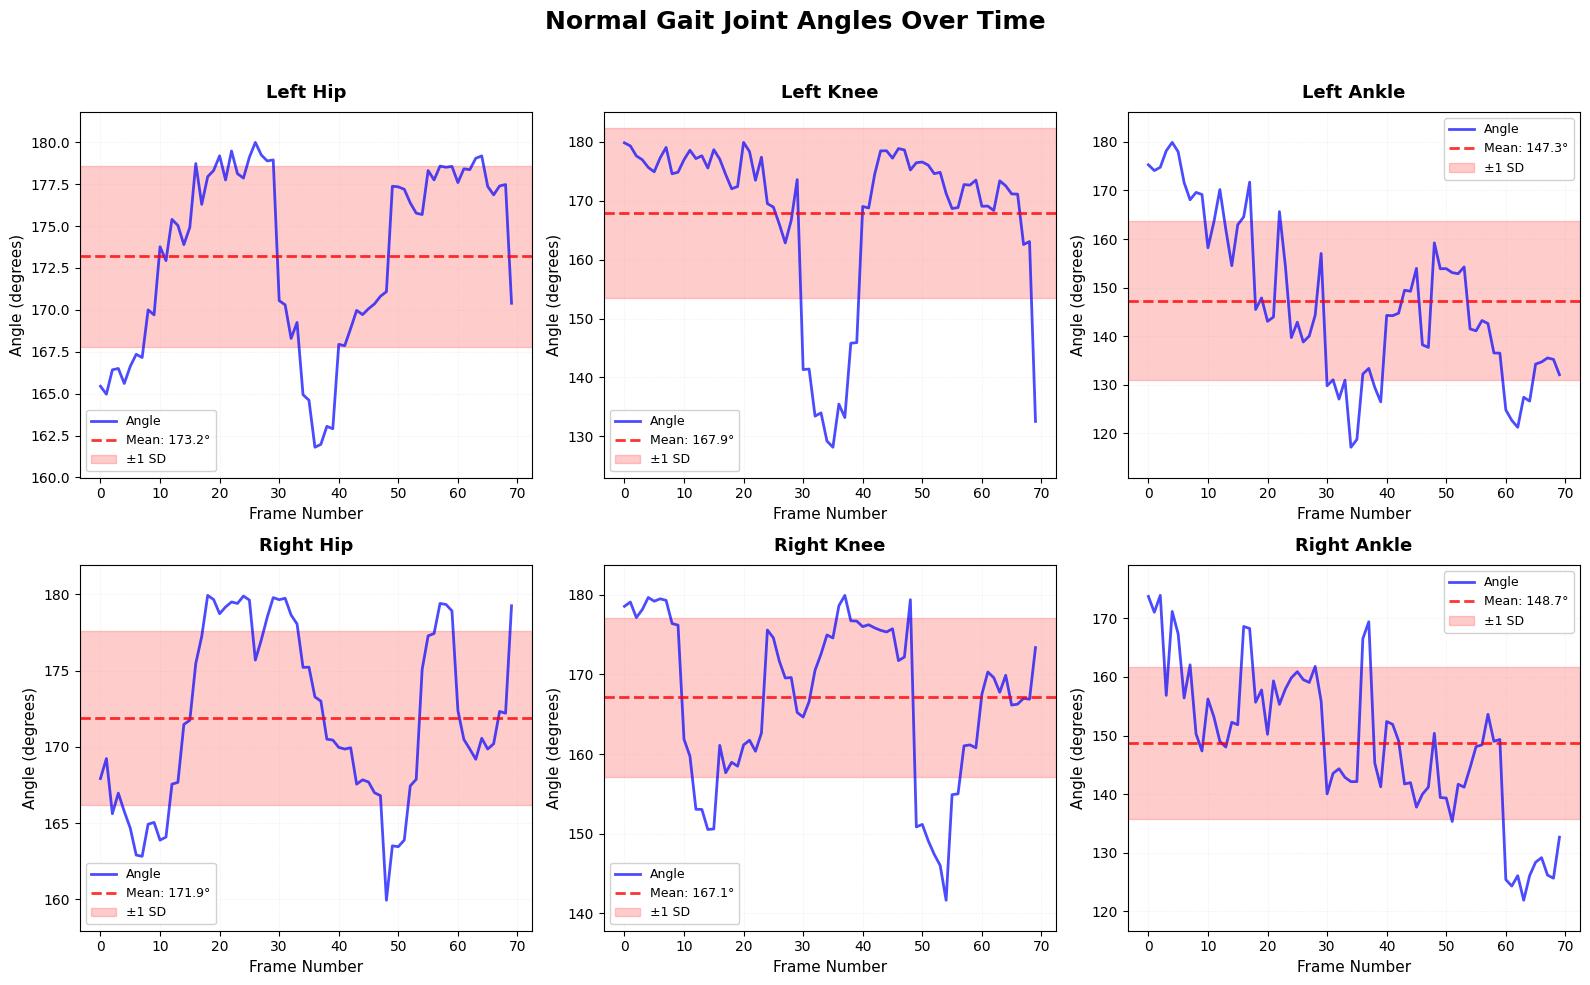


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           173.2°     5.4°   161.8°   180.0°    18.2°
left_knee          167.9°    14.4°   128.2°   179.9°    51.8°
left_ankle         147.3°    16.4°   117.2°   179.9°    62.7°
right_hip          171.9°     5.7°   159.9°   179.9°    20.0°
right_knee         167.1°    10.0°   141.6°   179.9°    38.3°
right_ankle        148.7°    13.0°   121.9°   173.9°    52.0°



In [25]:
plot_joint_angles_statistics("Normal Gait", normal_joint_angles)


Visualizing joint angles for Stroke Gait...
Number of frames with joint angles: 166


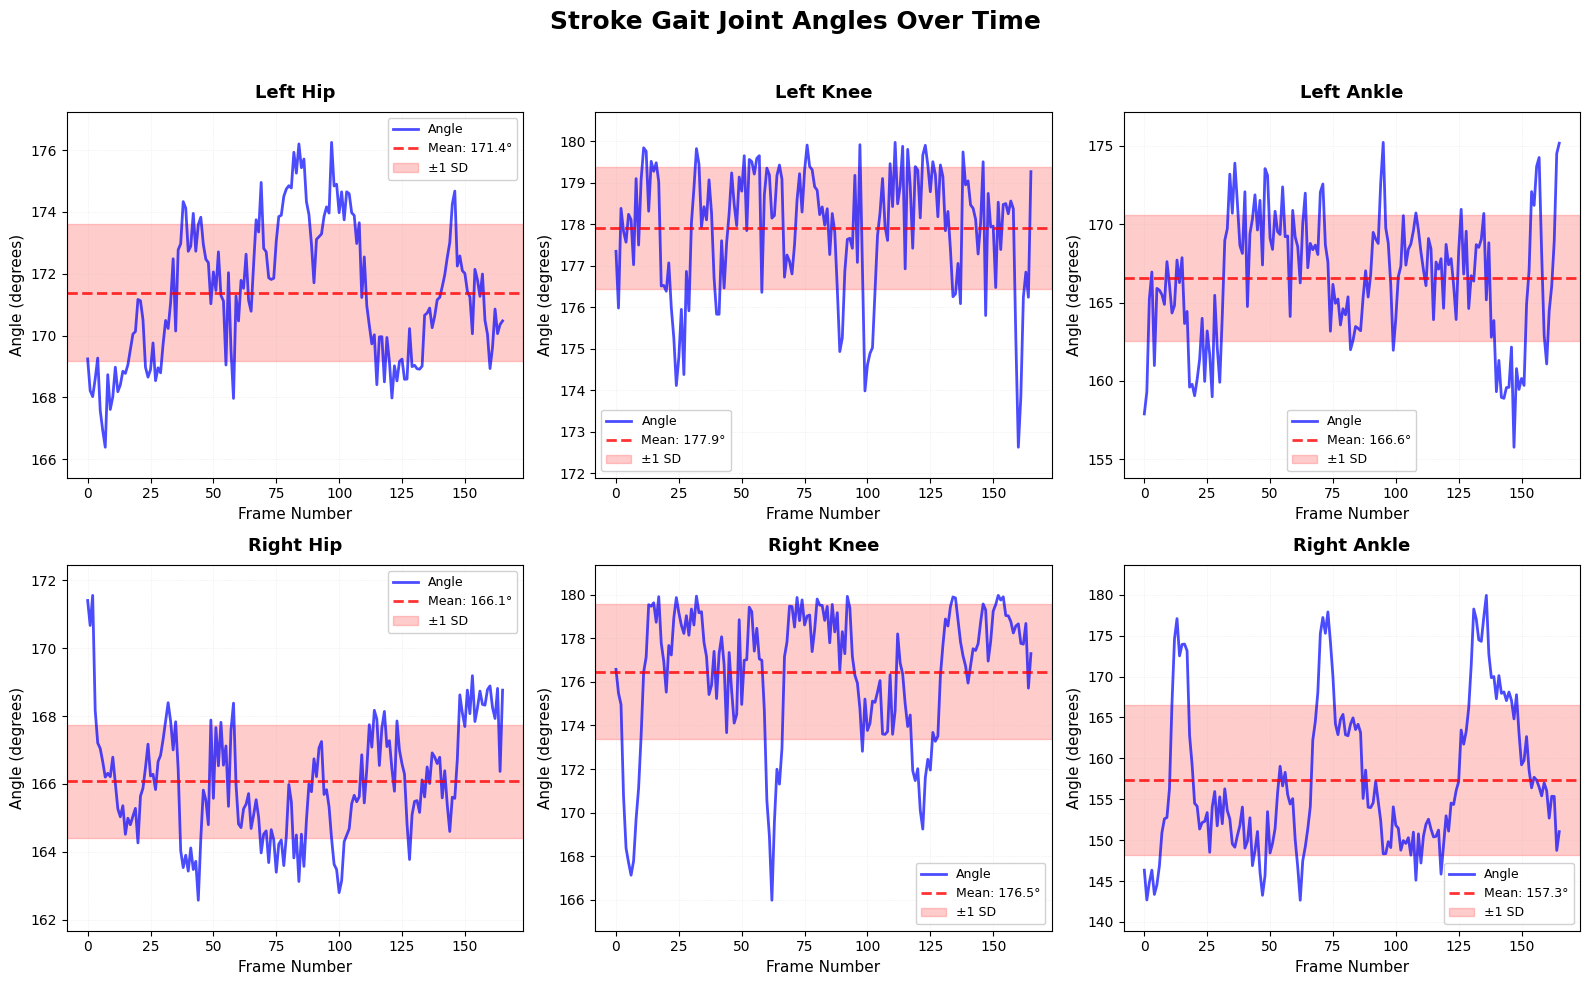


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           171.4°     2.2°   166.4°   176.3°     9.9°
left_knee          177.9°     1.5°   172.6°   180.0°     7.4°
left_ankle         166.6°     4.0°   155.8°   175.2°    19.5°
right_hip          166.1°     1.7°   162.6°   171.6°     9.0°
right_knee         176.5°     3.1°   166.0°   180.0°    14.0°
right_ankle        157.3°     9.1°   142.7°   179.9°    37.3°



In [26]:
plot_joint_angles_statistics("Stroke Gait", stroke_joint_angles)


Visualizing joint angles for Parkinsons Gait...
Number of frames with joint angles: 81


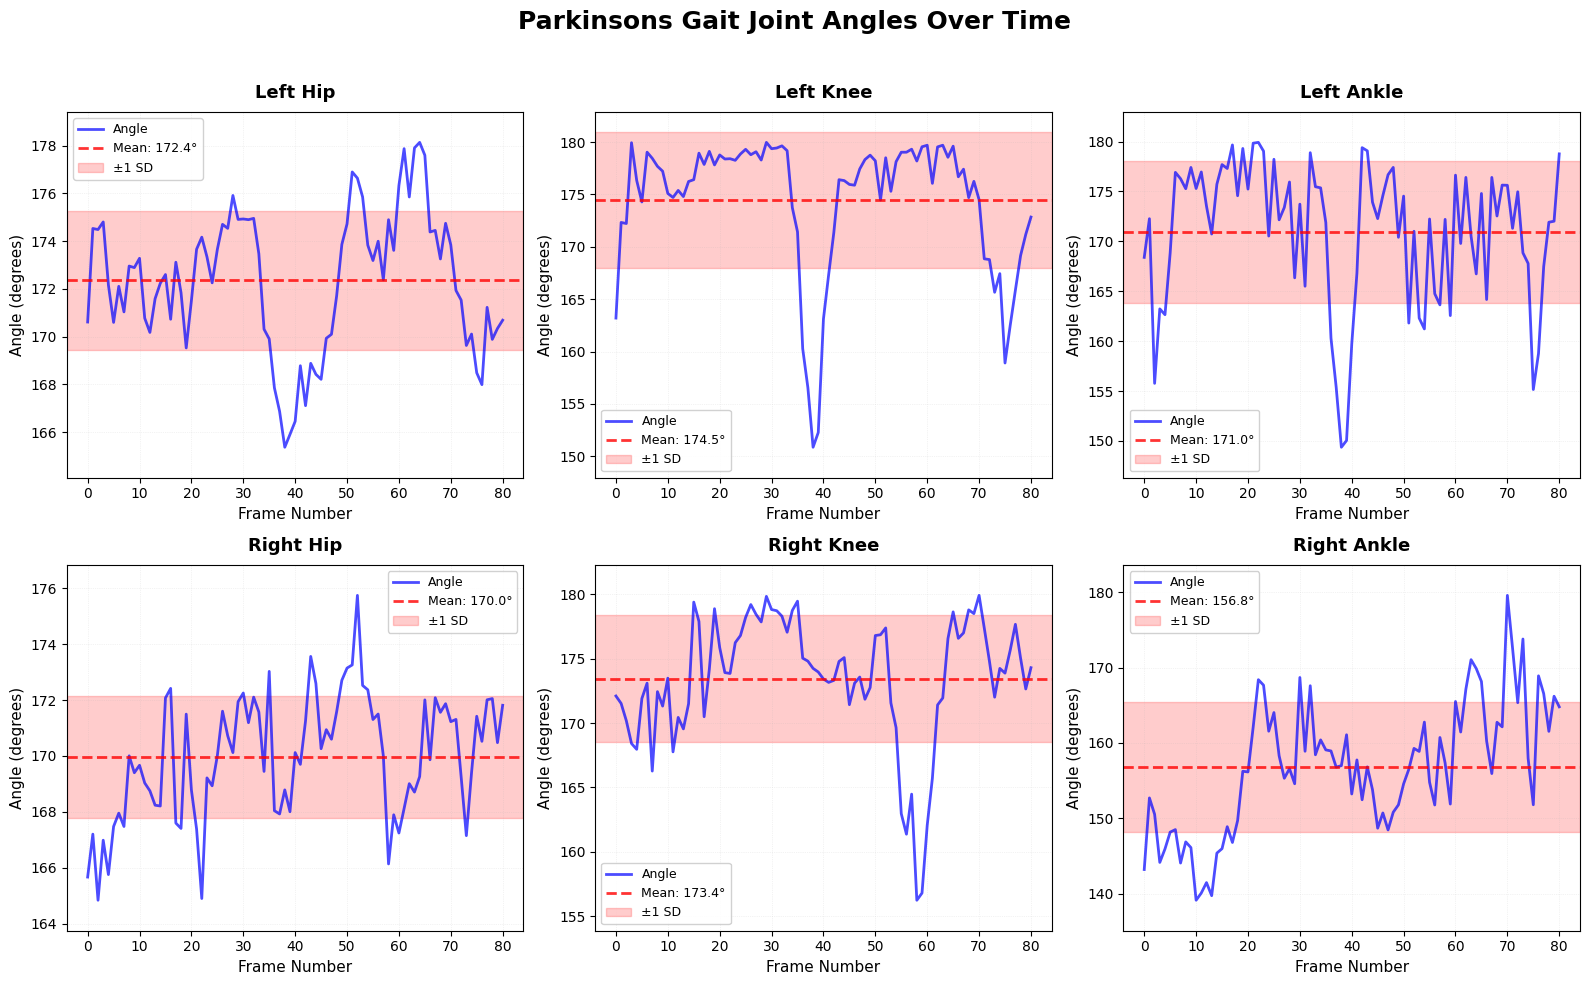


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           172.4°     2.9°   165.4°   178.1°    12.8°
left_knee          174.5°     6.5°   150.9°   180.0°    29.1°
left_ankle         171.0°     7.1°   149.4°   179.9°    30.6°
right_hip          170.0°     2.2°   164.8°   175.7°    10.9°
right_knee         173.4°     4.9°   156.3°   179.9°    23.6°
right_ankle        156.8°     8.6°   139.1°   179.6°    40.5°



In [27]:
plot_joint_angles_statistics("Parkinsons Gait", parkinsons_joint_angles)


Visualizing joint angles for Myopathic Gait...
Number of frames with joint angles: 144


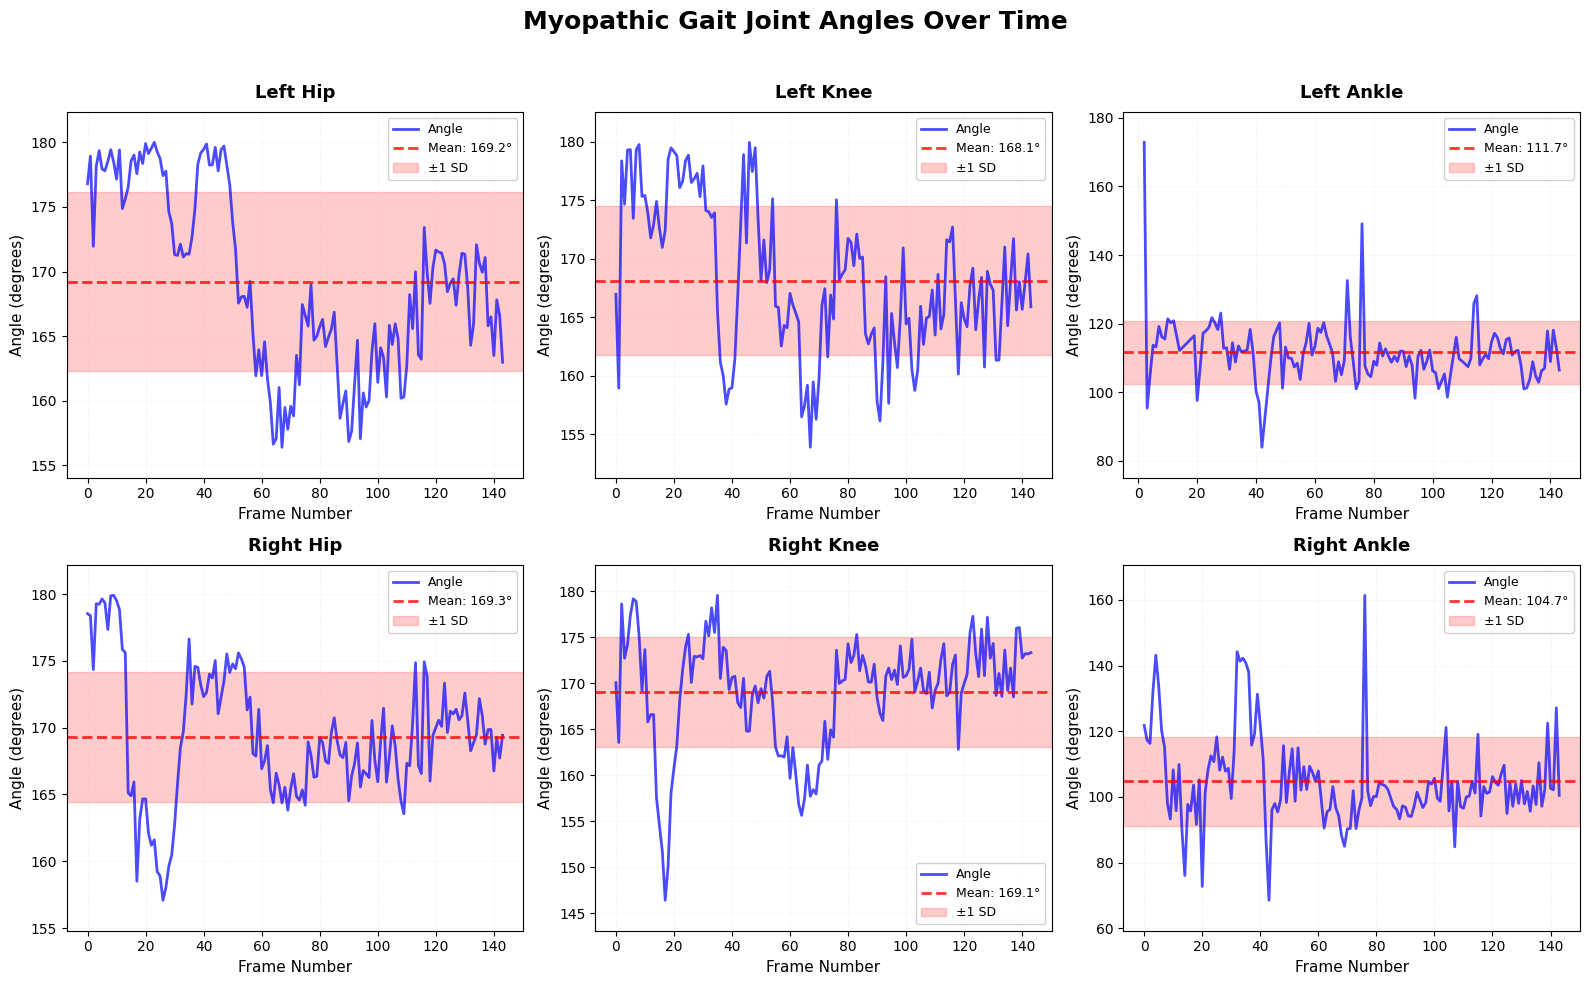


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           169.2°     6.9°   156.4°   180.0°    23.6°
left_knee          168.1°     6.4°   153.9°   180.0°    26.1°
left_ankle         111.7°     9.2°    84.0°   172.8°    88.8°
right_hip          169.3°     4.9°   157.1°   179.9°    22.8°
right_knee         169.1°     6.0°   146.4°   179.6°    33.1°
right_ankle        104.7°    13.6°    68.5°   161.4°    92.9°



In [28]:
plot_joint_angles_statistics("Myopathic Gait", myopathic_joint_angles)


Visualizing joint angles for Cerebral Palsy Gait...
Number of frames with joint angles: 152


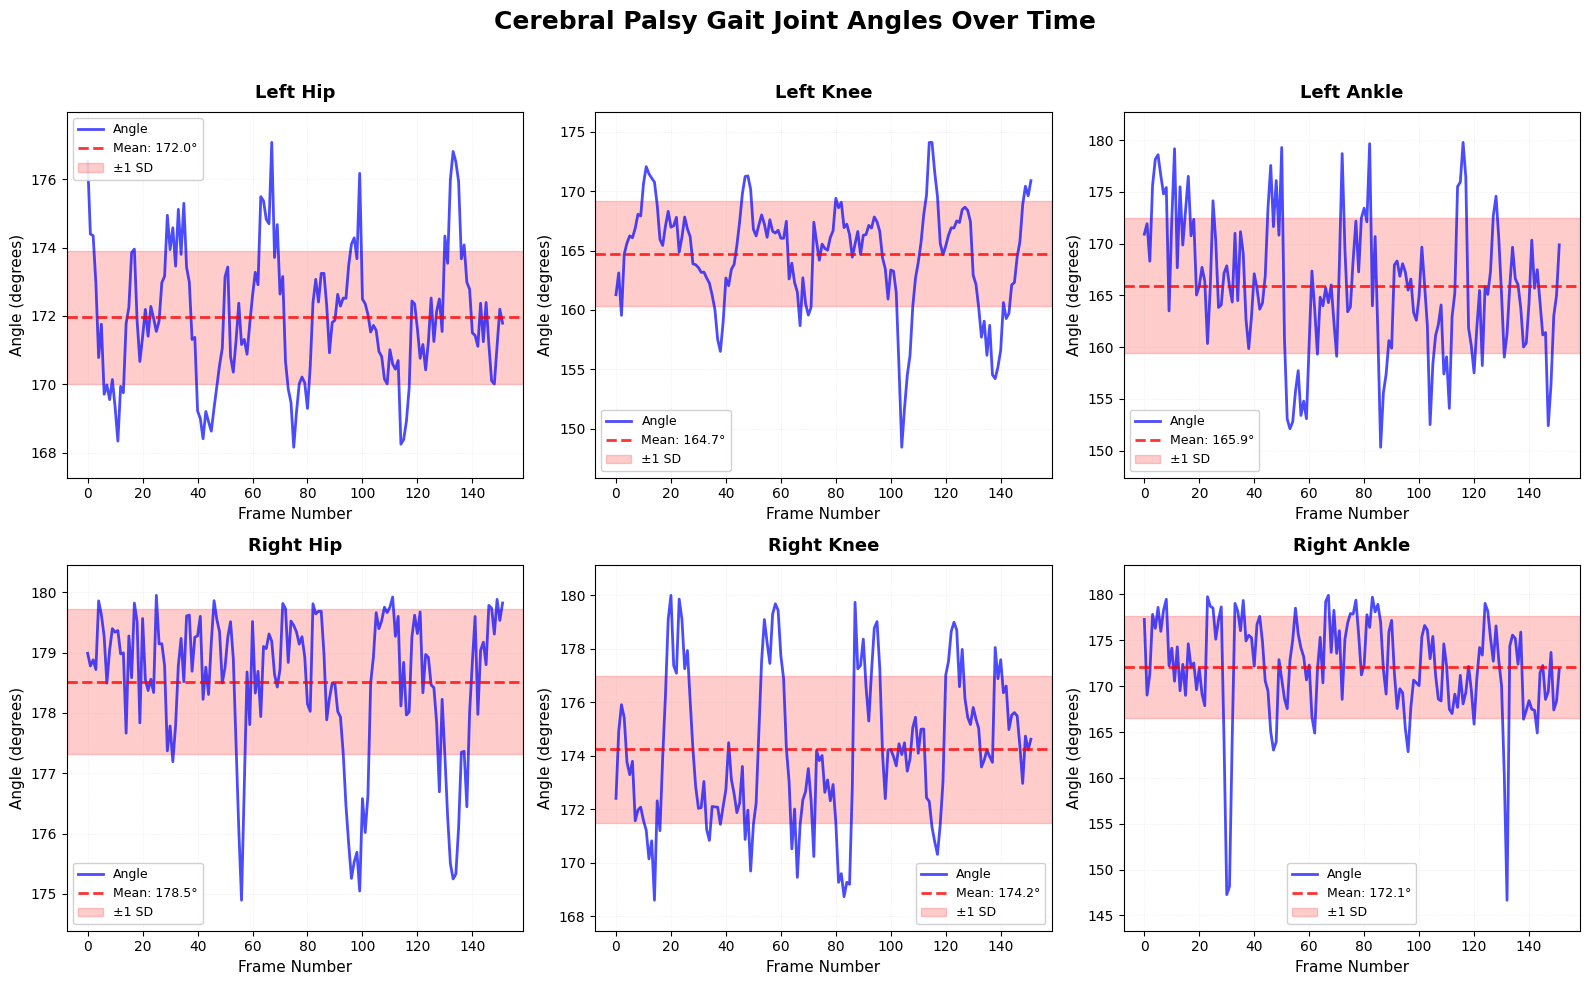


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           172.0°     1.9°   168.2°   177.1°     8.9°
left_knee          164.7°     4.4°   148.4°   174.1°    25.7°
left_ankle         165.9°     6.5°   150.3°   179.8°    29.5°
right_hip          178.5°     1.2°   174.9°   179.9°     5.1°
right_knee         174.2°     2.7°   168.6°   180.0°    11.4°
right_ankle        172.1°     5.6°   146.7°   179.9°    33.2°



In [29]:
plot_joint_angles_statistics("Cerebral Palsy Gait", cerebralpalsy_joint_angles)

## 5. Extract Features for Classification

In [30]:
from ambient.classification.features import GaitFeatureVector
from ambient.analysis.gait_analyzer import EnhancedGaitAnalyzer

In [35]:
# Convert keypoints to pose sequence format
pose_sequence = []
for kp_data in normal_keypoints_array:
    frame_dict = {
        "keypoints": [
            {"x": kp.x, "y": kp.y, "confidence": kp.confidence}
            for kp in kp_data.keypoints
        ],
        "frame_index": getattr(kp_data, 'frame_index', 0),
        "timestamp": getattr(kp_data, 'timestamp', 0.0)
    }
    pose_sequence.append(frame_dict)

# Step 3: Run enhanced analysis (for the new features)
analyzer = EnhancedGaitAnalyzer(keypoint_format="BLAZEPOSE_33", fps=30.0)
analysis_results = analyzer.analyze_gait_sequence(pose_sequence)

2026-01-27 16:06:22.218 | INFO     | ambient.analysis.feature_extractor:__init__:65 - Feature extractor initialized for BLAZEPOSE_33 format
2026-01-27 16:06:22.219 | DEBUG    | ambient.analysis.feature_extractor:__init__:66 - Extended features: True, Joint stats: True, Stability: True, Advanced temporal: True, Confidence threshold: 0.3
2026-01-27 16:06:22.219 | INFO     | ambient.analysis.temporal_analyzer:__init__:50 - Temporal analyzer initialized with heel_strike detection
2026-01-27 16:06:22.220 | INFO     | ambient.analysis.symmetry_analyzer:__init__:48 - Symmetry analyzer initialized for BLAZEPOSE_33 format
2026-01-27 16:06:22.220 | INFO     | ambient.analysis.gait_analyzer:__init__:756 - Enhanced gait analyzer initialized for BLAZEPOSE_33 format
2026-01-27 16:06:22.220 | DEBUG    | ambient.analysis.gait_analyzer:__init__:757 - Comprehensive features: True
2026-01-27 16:06:22.221 | INFO     | ambient.analysis.gait_analyzer:analyze_gait_sequence:791 - Extracting gait features...
2

In [36]:
# Add joint angle statistics to analysis_results
if "features" not in analysis_results:
    analysis_results["features"] = {}

# Extract joint angle statistics and add to features dict
for joint_name in ["left_hip", "left_knee", "left_ankle", "right_hip", "right_knee", "right_ankle"]:
    stats = normal_joint_angles.get_statistics(joint_name)
    analysis_results["features"][f"{joint_name}_mean"] = stats.get("mean", 0.0)
    analysis_results["features"][f"{joint_name}_range"] = stats.get("range", 0.0)

# Create feature vector with ALL features
feature_vector = GaitFeatureVector.from_analysis_results(
    analysis_results,
    sample_id=normal_sid,
    condition_label="normal"
)

if feature_vector:
    print("Feature Vector:")
    print(f"  Sample ID: {feature_vector.sample_id}")
    print(f"  Condition: {feature_vector.condition_label}")
    print(f"\nAll {len(GaitFeatureVector.get_feature_names())} Features:")
    for name in GaitFeatureVector.get_feature_names():
        value = getattr(feature_vector, name)
        print(f"  {name:30s}: {value:7.2f}")
else:
    print("Failed to extract features")


Feature Vector:
  Sample ID: cljo32213001u3n6lel97up5f
  Condition: normal

All 82 Features:
  left_hip_mean                 :  173.19
  left_knee_mean                :  167.92
  left_ankle_mean               :  147.31
  right_hip_mean                :  171.89
  right_knee_mean               :  167.12
  right_ankle_mean              :  148.73
  hip_asymmetry                 :    1.30
  knee_asymmetry                :    0.80
  ankle_asymmetry               :    1.43
  left_hip_range                :   18.19
  left_knee_range               :   51.77
  left_ankle_range              :   62.75
  right_hip_range               :   20.00
  right_knee_range              :   38.30
  right_ankle_range             :   52.02
  walking_speed_ms              :    0.30
  cadence_steps_min             :  109.09
  stride_length_m               :    0.01
  step_width_m                  :    0.36
  stance_percentage             :   69.31
  swing_percentage              :   25.33
  double_support_percenta

In [37]:
def extract_features_from_sequence(keypoints_array, seq_id, condition_name):
    """Extract all 34 features from a single sequence."""
    # Calculate joint angles for core features
    joint_angles = get_joint_angles(
        keypoints_array=keypoints_array,
        keypoint_format="BLAZEPOSE_33",
        fps=30.0,
        confidence_threshold=0.3,
        sequence_id=seq_id
    )
    
    if len(joint_angles.frames) == 0:
        return None
    
    # Convert keypoints to pose sequence format
    pose_sequence = [
        {
            "keypoints": [
                {"x": kp.x, "y": kp.y, "confidence": kp.confidence}
                for kp in kp_data.keypoints
            ],
            "frame_index": getattr(kp_data, 'frame_index', 0),
            "timestamp": getattr(kp_data, 'timestamp', 0.0)
        }
        for kp_data in keypoints_array
    ]
    
    # Run enhanced analysis
    analyzer = EnhancedGaitAnalyzer(keypoint_format="BLAZEPOSE_33", fps=30.0)
    analysis_results = analyzer.analyze_gait_sequence(pose_sequence)
    
    # # Merge joint angle statistics into results
    # if "features" not in analysis_results:
    #     analysis_results["features"] = {}
    
    # for joint in ["left_hip", "left_knee", "left_ankle", "right_hip", "right_knee", "right_ankle"]:
    #     stats = joint_angles.get_statistics(joint)
    #     analysis_results["features"][f"{joint}_mean"] = stats.get("mean", 0.0)
    #     analysis_results["features"][f"{joint}_range"] = stats.get("range", 0.0)
    
    # Create feature vector with all 34 features
    return GaitFeatureVector.from_analysis_results(
        analysis_results,
        sample_id=seq_id,
        condition_label=condition_name
    )


def extract_all_features(condition_paths, video_base_path):
    """Extract all 34 features from all condition directories."""
    from ambient.analysis.gait_analyzer import EnhancedGaitAnalyzer
    
    all_features = []
    condition_counts = defaultdict(int)
    gavd_loader = GAVDDataLoader()
    extractor = SequenceKeypointExtractor()
    
    for condition_path in condition_paths:
        condition_name = condition_path.name
        print(f"\nProcessing: {condition_name}")
        
        for csv_path in condition_path.glob("*.csv"):
            try:
                df = gavd_loader.load_gavd_data(str(csv_path))
                sequences = gavd_loader.organize_by_sequence(df)
                
                for seq_id, sequence_df in sequences.items():
                    try:
                        # Extract keypoints
                        keypoints_array = extractor.extract_from_sequence(
                            sequence_df,
                            video_base_path=video_base_path,
                            verbose=False
                        )
                        
                        if not keypoints_array:
                            continue
                        
                        # Extract all 34 features
                        feature_vector = extract_features_from_sequence(
                            keypoints_array, seq_id, condition_name
                        )
                        
                        if feature_vector:
                            all_features.append(feature_vector)
                            condition_counts[condition_name] += 1
                            print(f"  ✓ {seq_id}")
                        
                    except Exception as e:
                        print(f"  ✗ {seq_id}: {e}")
                        
            except Exception as e:
                print(f"  Error processing {csv_path.name}: {e}")
    
    return all_features, dict(condition_counts)


In [ ]:
# Feature extraction is only needed if it has not been done already
# Check if you have extracted_features.pkl in the same directory
all_features, condition_counts = extract_all_features(condition_paths, video_base_path)

print(f"\n{'='*60}")
print(f"Total features extracted: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
    print(f"  {condition:15s}: {count:3d} samples")


Processing: stroke


2026-01-27 16:07:13.615 | INFO     | ambient.analysis.feature_extractor:__init__:65 - Feature extractor initialized for BLAZEPOSE_33 format
2026-01-27 16:07:13.616 | DEBUG    | ambient.analysis.feature_extractor:__init__:66 - Extended features: True, Joint stats: True, Stability: True, Advanced temporal: True, Confidence threshold: 0.3
2026-01-27 16:07:13.616 | INFO     | ambient.analysis.temporal_analyzer:__init__:50 - Temporal analyzer initialized with heel_strike detection
2026-01-27 16:07:13.616 | INFO     | ambient.analysis.symmetry_analyzer:__init__:48 - Symmetry analyzer initialized for BLAZEPOSE_33 format
2026-01-27 16:07:13.616 | INFO     | ambient.analysis.gait_analyzer:__init__:756 - Enhanced gait analyzer initialized for BLAZEPOSE_33 format
2026-01-27 16:07:13.617 | DEBUG    | ambient.analysis.gait_analyzer:__init__:757 - Comprehensive features: True
2026-01-27 16:07:13.617 | INFO     | ambient.analysis.gait_analyzer:analyze_gait_sequence:791 - Extracting gait features...
2

  ✓ cljvvsucg00043n6l4evgn7q4


2026-01-27 16:07:13.978 | WARNING  | ambient.pose.keypoint_extractor:_process_frame:506 - Keypoint extraction returned 0 keypoints for frame 1739
I0000 00:00:1769558896.150858 44776896 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1769558896.203504 44776898 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769558896.213030 44776908 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-27 16:08:44.499 | INFO     | ambient.analysis.feature_extractor:__init__:65 - Feature extractor initialized for BLAZEPOSE_33 format
2026-01-27 16:08:44.500 | DEBUG    | ambient.analysis.feature_extractor:__init__:66 - Extended features: True, Joint stats: True, Stability: True, Advanced temporal: True, Confidence threshold: 0.3
2026-01-27 16:08:44.500 | INFO   

  ✓ cljr5jk0h000n3n6la34mkdfz


...

  ✓ cljas04fw00f33n6lm5cvx9g6


2026-01-27 17:30:37.222 | WARNING  | ambient.pose.keypoint_extractor:_process_frame:506 - Keypoint extraction returned 0 keypoints for frame 952
2026-01-27 17:32:07.489 | INFO     | ambient.analysis.feature_extractor:__init__:65 - Feature extractor initialized for BLAZEPOSE_33 format
2026-01-27 17:32:07.489 | DEBUG    | ambient.analysis.feature_extractor:__init__:66 - Extended features: True, Joint stats: True, Stability: True, Advanced temporal: True, Confidence threshold: 0.3
2026-01-27 17:32:07.490 | INFO     | ambient.analysis.temporal_analyzer:__init__:50 - Temporal analyzer initialized with heel_strike detection
2026-01-27 17:32:07.490 | INFO     | ambient.analysis.symmetry_analyzer:__init__:48 - Symmetry analyzer initialized for BLAZEPOSE_33 format
2026-01-27 17:32:07.490 | INFO     | ambient.analysis.gait_analyzer:__init__:756 - Enhanced gait analyzer initialized for BLAZEPOSE_33 format
2026-01-27 17:32:07.490 | DEBUG    | ambient.analysis.gait_analyzer:__init__:757 - Comprehen

  ✓ cljas2sou00ff3n6lasppj8h2


I0000 00:00:1769563957.067345 46092877 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1769563957.117752 46092879 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769563957.127333 46092880 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1769564129.241398 46127435 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1769564129.294278 46127437 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769564129.304140 46127447 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-27 17:35:59.600 | INFO    

  ✓ cljarcy3g00co3n6lzsn1x034

Total features extracted: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples
CPU times: user 7min 19s, sys: 4min 4s, total: 11min 24s
Wall time: 1h 29min 18s


### Save and Load Feature Data

Let's create functions to save and load the extracted features to avoid re-extracting them every time.

In [39]:
from ambient.utils.features_utils import save_features, load_features

FILENAME="all82_features.pkl"
DIRECTORY="features"
save_path = save_features(all_features, condition_counts, filename=FILENAME, directory=DIRECTORY)

print(f"\nFeatures saved to: {save_path}")

✓ Features saved successfully to: features/all82_features.pkl
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']
  File size: 67.85 KB

Features saved to: features/all82_features.pkl


### Load Previously Extracted Features

To load previously saved features instead of re-extracting them, uncomment and run the cell below:

In [40]:
all_features, condition_counts = load_features(filename=FILENAME, directory=DIRECTORY)
print(f"\n{'='*60}")
print(f"Total features loaded: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
     print(f"  {condition:15s}: {count:3d} samples")

✓ Features loaded successfully from: features/all82_features.pkl
  Saved on: 2026-01-27T18:18:09.623427
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']

Total features loaded: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples
